This notebook is used to "unit" test the ellipsoidal and reflection effects against simple PHOEBE systems to ensure behavior is correct. This is done by generating the lightcurves for various combinations of orbital parameters and then verifing that eBEER can replicate this result either implicitly or with fitting for reflection. 

This notebook is useful for quick tests of few combinations of orbital parameters to verify behaviors or other quick tests. For longer tests use "PHOEBEUnitTestingScript.py".

It is of note that the testing for reflection effect also includes the ellipsoidal effect so it can only be used as a confirmation of reflection assuming the ellipsoidal effect works. I do this as my code in "phoebe_to_eBEER.py" does not readily have a way to turn of the ellipsoidal effect because the $\alpha$ scaling coefficients are calculated from the linear limb and gravity darkening coefficients. It would not be too difficult to add a new boolean to toggle ellipsoidal but, I wanted to avoid messing with my code in "phoebe_to_eBEER.py" unless necessary.

We start by importing the necessary packages:
 - numpy, pandas, matplotlib
 - phoebe
 - astropy.units - used to ensure PHOEBE understand what units we are working with
 - scipy.optimize.curve_fit - for fitting
 - testing_utils - a .py file with some general tools for constructing and printing PHOEBE binaries
 - phoebe_to_eBEER - .py file containing model code to take a phoebe binary and return eBEER model light curve

In [1]:
import phoebe

import sys
sys.path.insert(1, '../scripts')
from phoebe_to_ebeer import get_ebeer_lc
import testing_utils as utils

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from scipy.optimize import curve_fit

import itertools
import time

We start by making a list of various parameters we would like to test for. If you would like to look at specific system that are not combinations of the same sets then you must set comb_list by hand.

We can easily toggle the reflection effect (and necessary testing steps like fitting) with the `Refl_ON` boolean

In [2]:
eccs = (0.8,)#(0, 0.3, 0.8,)
incls = (30,)#(0, 30, 60, 90, 120, 150, 180,)
per0s = (0, 30, 90, 150, 180, 240,)
qs = (1,)#(1, 0.5, 2,)
ps = (5,)#(1, 5, 10, 15, 20,)

combinations = itertools.product(eccs, incls, per0s, ps, qs)
comb_list = list(combinations)
# comb_list = ((0,0,0,1,1),)

Refl_ON = False

PHOEBE returns absolute flux so we must convert this to relative flux with the flux of the system with all effects turned off as the reference (this is the modulating eBEER calculates). To do this we initialize the first phoebe_binary and simulate the lightcurve with the effects on and then initialize the second binary and simulate its light curve with all effects off.

We set passband to Kepler and use Phoenix as the atmosphere model. We can also conveniently turn of eclipses with `'eclipse_method'='only_horizon'`.
We can turn off reflection with `'irrad_method'='none'` and ellipsoidal with `'distortion_method'='sphere'`. We have to turn off ellipsoidal for both stars which can be easily accomploshed with `set_value_all()`.
The last high level modification of note is `'ntriangles'`. For systems with $Porb < 1$ 10k triangles is more than sufficient. For higher orbital periods more triangles (100k) is needed to not lose the signal to noise. However even this stops working at $Porb >= 100$. Make sure to use the same ntriangles for both phoebe binaries.

A few notes on certain choices made in the following algorithm:
- I keep the following all in one cell so that the PHOEBE binaries are recreated each time we test different combinations to avoid any issues where the object is already in memory.
- I chose to set the values in the loop each time as opposed to using the get_phoebe_binary function I have already created as this is significantly faster. phoebe.default_binary() takes a few seconds so creating a new binary for each combination would be inefficient.
- I set the stellar radii to their max according to PHOEBE as sometimes- for higher eccentricities- q**0.8 is even larger and would have the star overflowing at periastron

['roche', 'rotstar', 'sphere', 'none']
System: lc_5_8_30_0_10
	System Setup Duration: 1.3544957637786865
Orbit - e: 0.8,  i: 30.0,  $\omega$: 0.0,  Porb: 5.0,  t0_periastron: -0.1301100483272848,  q: 1.0
Star 1 - M1: 1.0,  R1: 1.0,  T1: 6000.0,  Prot1: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.9999999999999996,  R2: 1.0,  T2: 6000.0,  Prot2: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:11<00:00,  8.72it/s]


	LC Dataset Duration: 12.190864086151123


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 22.30it/s]


	Total Duration: 16.945794582366943
PHOEBED lc: array([ 1357.95227388,  1021.73234043,   895.00641253,   819.34086465,
         757.72247644,   697.30648235,   660.93033781,   632.38884131,
         606.10289098,   584.83197155,   559.4490607 ,   548.11707118,
         539.90121233,   525.69576433,   512.17426943,   513.05692811,
         498.74303479,   495.88348473,   480.92851519,   490.16148627,
         476.4251189 ,   482.35022038,   478.97944604,   473.09630826,
         462.54434887,   470.49149793,   470.16990851,   462.78558279,
         456.66773868,   464.50581832,   459.33885291,   454.50375478,
         453.21981963,   453.30623461,   444.55086846,   455.12908376,
         447.83451265,   444.01838119,   445.80099708,   444.47610264,
         449.1359032 ,   455.78212488,   451.46314347,   450.41377213,
         463.23773541,   454.69233652,   454.33069679,   458.17569069,
         445.94058773,   455.57205878,   455.14562989,   451.14531792,
         457.13762448,   454.

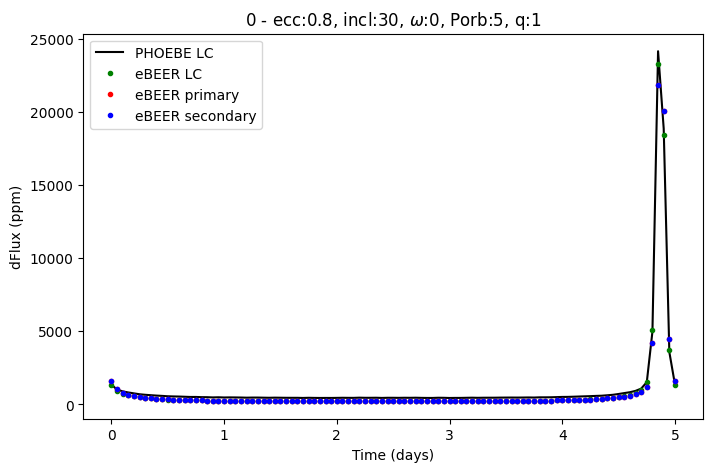

System: lc_5_8_30_30_10
	System Setup Duration: 0.7109510898590088
Orbit - e: 0.8,  i: 30.0,  $\omega$: 30.0,  Porb: 5.0,  t0_periastron: -0.06631048348556662,  q: 1.0
Star 1 - M1: 1.0,  R1: 1.0,  T1: 6000.0,  Prot1: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.9999999999999996,  R2: 1.0,  T2: 6000.0,  Prot2: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:11<00:00,  8.89it/s]


	LC Dataset Duration: 11.963522672653198


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 16.52it/s]


	Total Duration: 14.202668190002441
PHOEBED lc: array([ 3353.81601778,  2673.25274432,  2265.31411113,  1863.28581683,
        1573.17831164,  1377.63896298,  1231.79828765,  1122.86961008,
        1058.07934561,   995.12713771,   955.77241977,   922.0918422 ,
         898.54884748,   878.01829475,   864.70437184,   834.80119965,
         835.05398633,   820.25012222,   813.14885625,   798.74127444,
         788.23238327,   796.9587661 ,   782.17361028,   784.25347039,
         785.87056104,   777.31109729,   768.43015183,   769.03478518,
         756.50910666,   760.25672565,   761.25854778,   760.39523661,
         754.09654367,   756.48614109,   754.14773098,   751.43584241,
         746.33746714,   732.74610749,   737.56166792,   740.99830093,
         738.94521722,   745.61308136,   749.22890234,   745.55063814,
         747.08578037,   747.25395337,   742.03286051,   745.85762958,
         747.31890286,   744.59202052,   745.52818362,   742.32972388,
         741.82085225,   738.

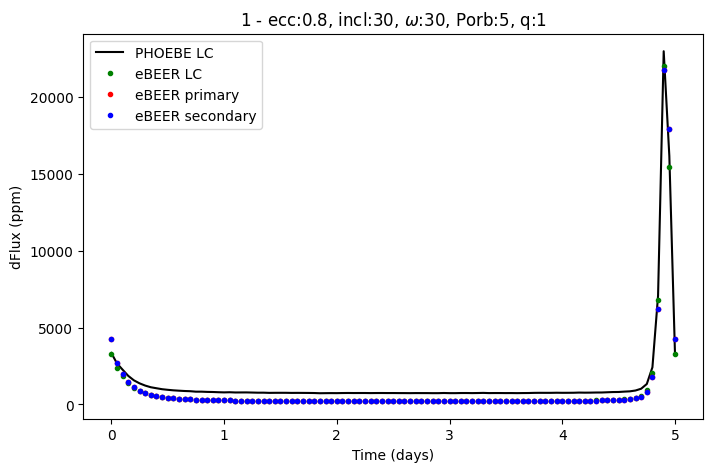

System: lc_5_8_30_90_10
	System Setup Duration: 0.5748538970947266
Orbit - e: 0.8,  i: 30.0,  $\omega$: 90.0,  Porb: 5.0,  t0_periastron: 0.0,  q: 1.0
Star 1 - M1: 1.0,  R1: 1.0,  T1: 6000.0,  Prot1: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.9999999999999996,  R2: 1.0,  T2: 6000.0,  Prot2: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:11<00:00,  9.04it/s]


	LC Dataset Duration: 11.753089427947998


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 23.83it/s]


	Total Duration: 13.89206600189209
PHOEBED lc: array([ 6813.52107754, 11884.66650244,  7829.20616869,  4258.04510842,
        2612.66689861,  1829.0028197 ,  1436.13025058,  1220.42827765,
        1078.64867727,  1002.41723624,   938.08102255,   899.39140829,
         868.328859  ,   875.50426556,   836.72371899,   822.23647523,
         814.65856909,   802.63356379,   788.49872386,   792.20372087,
         789.17603085,   794.41002954,   767.35575595,   774.49867607,
         779.26793726,   772.56396424,   776.15875024,   775.94405736,
         771.09749955,   773.29820582,   769.0452026 ,   767.88359062,
         760.81707448,   757.21096204,   759.76506801,   767.41526428,
         759.34320224,   767.1964989 ,   772.77849544,   766.40909352,
         763.52858591,   755.94859072,   766.64790429,   765.34941396,
         761.62159105,   765.78929607,   757.7955124 ,   770.9166119 ,
         752.79238279,   752.0968512 ,   768.75943292,   760.59450202,
         771.32506506,   775.3

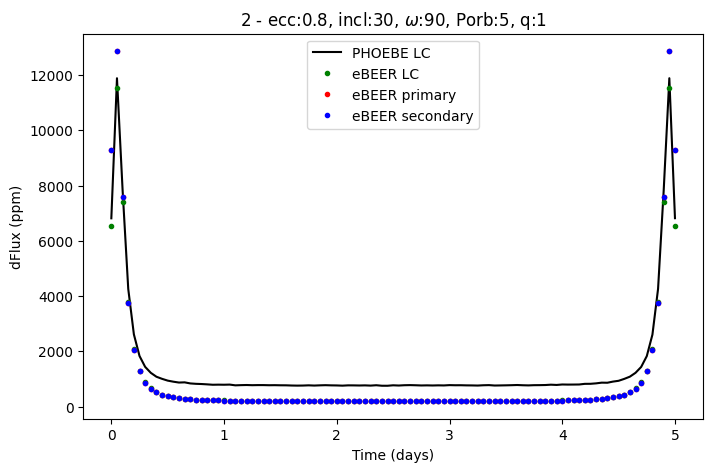

System: lc_5_8_30_150_10
	System Setup Duration: 0.5941684246063232
Orbit - e: 0.8,  i: 30.0,  $\omega$: 150.0,  Porb: 5.0,  t0_periastron: 0.06631048348556662,  q: 1.0
Star 1 - M1: 1.0,  R1: 1.0,  T1: 6000.0,  Prot1: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.9999999999999996,  R2: 1.0,  T2: 6000.0,  Prot2: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:11<00:00,  8.90it/s]


	LC Dataset Duration: 11.892013549804688


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 23.97it/s]


	Total Duration: 13.94577431678772
PHOEBED lc: array([ 3353.81601778, 16174.72871999, 22989.54875669,  7090.02401779,
        2418.66454638,  1332.77859486,  1029.35802189,   914.84999494,
         857.38319647,   832.11693833,   812.43177118,   803.27371484,
         796.39106829,   789.0672556 ,   786.92789292,   774.7519188 ,
         769.8279671 ,   766.44872787,   764.43435891,   770.1981666 ,
         763.30420854,   767.1897032 ,   754.26755033,   757.81581394,
         751.91826382,   758.99461968,   745.2152555 ,   745.20432205,
         747.94900299,   744.34165221,   745.6991599 ,   747.28003165,
         742.01365896,   742.01978395,   741.03403051,   755.91768156,
         738.9743151 ,   750.58234533,   748.38444607,   738.42947763,
         748.93879234,   736.89611812,   738.30376959,   743.05413108,
         740.46403943,   737.70274924,   735.02536059,   734.24048894,
         738.33545001,   738.34528249,   745.07879327,   746.11960399,
         739.87649299,   746.6

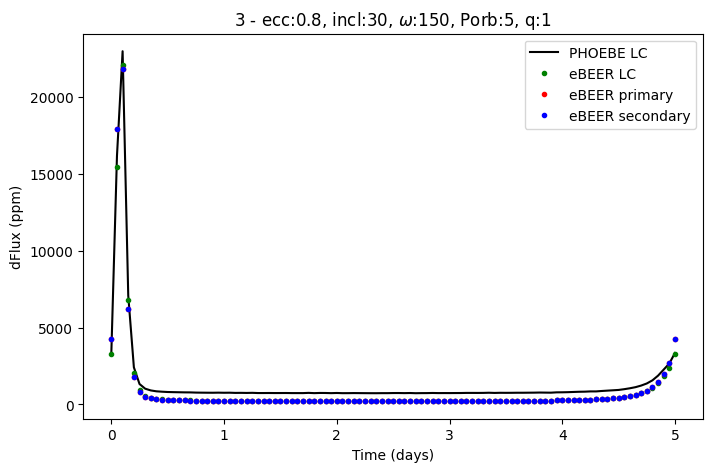

System: lc_5_8_30_180_10
	System Setup Duration: 0.5878243446350098
Orbit - e: 0.8,  i: 30.0,  $\omega$: 180.0,  Porb: 5.0,  t0_periastron: 0.1301100483272848,  q: 1.0
Star 1 - M1: 1.0,  R1: 1.0,  T1: 6000.0,  Prot1: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.9999999999999996,  R2: 1.0,  T2: 6000.0,  Prot2: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:11<00:00,  8.72it/s]


	LC Dataset Duration: 12.127960920333862


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 25.30it/s]


	Total Duration: 14.135701417922974
PHOEBED lc: array([ 1357.95227388,  3577.79094496, 18854.24942761, 24135.24511361,
        4969.42477343,  1520.54073017,  1056.22848514,   924.69033626,
         839.62515202,   765.89751548,   703.9068153 ,   668.46259801,
         628.98771996,   601.6394327 ,   578.68887582,   571.66783418,
         553.4166294 ,   539.78545978,   524.89669115,   515.31149706,
         506.20990642,   499.1392698 ,   495.10640189,   493.79909957,
         486.19490984,   480.07355885,   481.49054382,   480.15724437,
         470.83780269,   471.59303252,   467.17009421,   469.52715432,
         472.27554865,   467.57779112,   464.22031337,   456.43573124,
         464.33502823,   453.04488519,   452.84075205,   459.1410744 ,
         454.92423391,   458.83007754,   450.60232445,   437.57840357,
         437.41717154,   450.75499631,   455.90482637,   450.61915102,
         457.58340127,   453.88124748,   458.88913582,   454.48212111,
         454.78572534,   444.

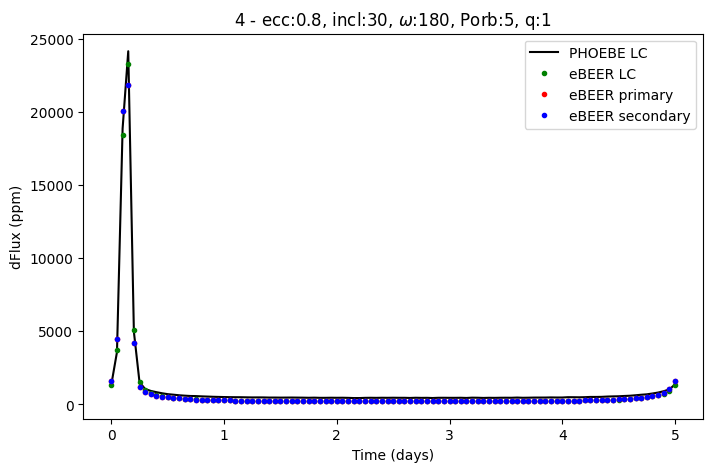

System: lc_5_8_30_240_10
	System Setup Duration: 0.5868186950683594
Orbit - e: 0.8,  i: 30.0,  $\omega$: 240.0,  Porb: 5.0,  t0_periastron: 0.8006494028177051,  q: 1.0
Star 1 - M1: 1.0,  R1: 1.0,  T1: 6000.0,  Prot1: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32
Star 2 - M2: 0.9999999999999996,  R2: 1.0,  T2: 6000.0,  Prot2: 5.0,  Limb Dark. Coeff: [0.5],  Grav Dark. Coeff: 0.32


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:10<00:00,  9.22it/s]


	LC Dataset Duration: 11.478993892669678


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 22.50it/s]


	Total Duration: 13.539267301559448
PHOEBED lc: array([  217.36691517,   225.00769921,   229.3806846 ,   224.80847826,
         226.96660565,   248.84973459,   264.26654682,   297.36628795,
         331.72279294,   396.46245462,   516.39082506,   768.42616393,
        1311.86481916,  2717.55630848,  6824.44968479, 16765.94561149,
       12201.88557469,  5007.36919014,  4926.59770037,  3284.48030747,
        2120.66952611,  1466.01075892,  1067.02369799,   814.86650548,
         674.45166034,   567.43016493,   484.30734037,   433.46210044,
         381.70862447,   354.41183116,   337.47465036,   316.08697507,
         293.67773621,   287.13919704,   282.34650749,   269.57096919,
         262.40689034,   253.65839847,   246.94489206,   242.45365915,
         237.60774789,   239.2314555 ,   226.33572464,   227.32842862,
         221.97718687,   224.97845872,   223.14365519,   216.3519737 ,
         219.25474279,   212.85561111,   211.14490653,   210.75353776,
         206.61004839,   209.

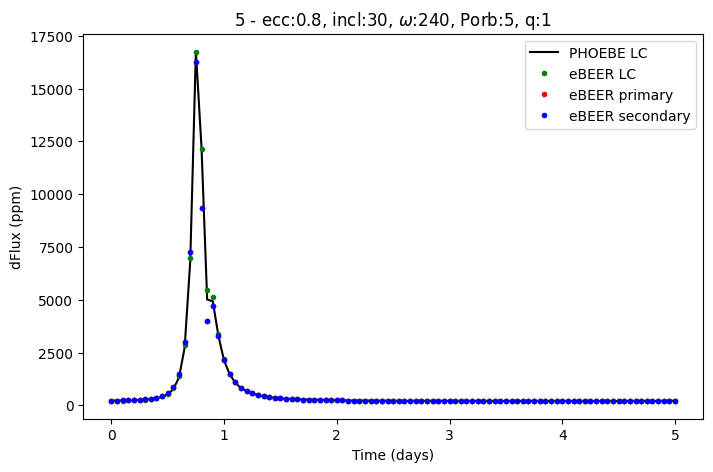

In [3]:
start = time.time()

# Initialize Binary with Effects ON
b_ = phoebe.default_binary()
b_.add_dataset('lc', times=0, label= 'lc01')
b_.set_value_all('gravb_bol', 0.32)
b_.set_value_all('ld_mode*', 'manual')
b_.set_value_all('ld_func*', 'linear')
b_.set_value_all('ld_coeffs*', 0.5)
b_.set_value_all('ntriangles', 10000)
b_['eclipse_method'] = 'only_horizon'
b_['passband'] = 'Bolometric:900-40000'
b_.set_value_all('atm', 'phoenix')
b_.flip_constraint('mass@primary', solve_for='sma')
b_.set_value_all('distortion_method', value='roche')
print(b_.get_parameter(context='compute', component='primary', qualifier='distortion_method').get_choices())
if Refl_ON:
    b_.set_value('irrad_method', 'horvat')
else:
    b_.set_value('irrad_method', 'none')

# Initialize Binary with Effects OFF
b_2 = phoebe.default_binary()
b_2.add_dataset('lc', times=0, label= 'lc01')
b_2.set_value_all('gravb_bol', 0.32)
b_2.set_value_all('ld_mode*', 'manual')
b_2.set_value_all('ld_func*', 'linear')
b_2.set_value_all('ld_coeffs*', 0.5)
b_2.set_value_all('ntriangles', 10000)
b_2['eclipse_method'] = 'only_horizon'
b_2['passband'] = 'Bolometric:900-40000'
b_2.set_value_all('atm', 'phoenix')
b_2.flip_constraint('mass@primary', solve_for='sma')
b_2.set_value('irrad_method', 'none')
b_2.set_value_all('distortion_method', value='sphere')


def fit_scaling(arefl1, arefl2):
    scaled = np.zeros(2)
    scaled[0] = arefl1 * 7
    scaled[1] = arefl2 * 7
    return scaled

def fit_ebeer(t, arefl1, arefl2):
    scaled = fit_scaling(arefl1, arefl2)
    flux = get_ebeer_lc(b_, t, 0, 0, scaled[0], scaled[1])
    return flux


periods = np.zeros(len(comb_list))
phoebe_ampl = np.zeros(len(comb_list))
ebeer_ampl = np.zeros(len(comb_list))
RMSDs = np.zeros(len(comb_list))

for i, comb in enumerate(comb_list):
    start_sys = time.time()
    ecc, incl, per0, p, q = comb
    comb_str = f'lc_{p}_{int(ecc*10)}_{incl}_{per0}_{int(q*10)}'
    print('System:', comb_str)

    # Configure Binary with Effects ON
    times = np.linspace(0,p,101)
    b_['lc01@dataset@times']= times
    b_['lc01@phases_t0'] = 't0_supconj'
    b_['orbit@period'].set_value(p * u.day)
    b_['orbit@incl'].set_value(incl * u.deg)
    b_['orbit@ecc'].set_value(ecc)
    b_['orbit@per0'].set_value(per0 * u.deg)
    b_['mass@primary@component'].set_value(1 * u.M_sun)
    b_['orbit@q'].set_value(q)
    b_.run_checks_compute()
    R1_max = b_['primary@component@requiv_max'].get_value(u.R_sun)
    R2_max = b_['secondary@component@requiv_max'].get_value(u.R_sun)
    b_['primary']['requiv'].set_value(min(1, R1_max) * u.R_sun)
    b_['secondary']['requiv'].set_value(min(q**0.8, R2_max) * u.R_sun)
    setup_done = time.time()
    print('\tSystem Setup Duration:', setup_done - start_sys)
    utils.print_pb_params(b_)

    # try: # Will hide any combinations that are failing due to falling outside 
         # of valid atmosphere tables or similar issues
    b_.run_compute(model= comb_str, overwrite= True)
    lc_done = time.time()
    print('\tLC Dataset Duration:', lc_done - setup_done)
    # except:
    #     print('\tFAILED COMPUTE')
    #     continue

    # Configure Binary with Effects OFF
    b_2['orbit@period'].set_value(p * u.day)
    b_2['orbit@incl'].set_value(incl * u.deg)
    b_2['orbit@ecc'].set_value(ecc)
    b_2['orbit@per0'].set_value(per0 * u.deg)
    b_2['mass@primary@component'].set_value(1 * u.M_sun)
    b_2['orbit@q'].set_value(q)
    #b_2['primary']['requiv'].set_value(R1_max * u.R_sun)
    #b_2['secondary']['requiv'].set_value(R2_max * u.R_sun)
    b_2['primary']['requiv'].set_value(1 * u.R_sun)
    b_2['secondary']['requiv'].set_value(q**0.8 * u.R_sun)
    # utils.print_pb_params(b_2)
    b_2.run_compute(overwrite= True)

    flux = b_[f'fluxes@lc01@{comb_str}@model'].value
    ref_flux = b_2['fluxes@lc01@latest@model'].value
    relative_flux_ = (flux - ref_flux)/ref_flux * 1e6


    if not Refl_ON:
        ebeer_flux = get_ebeer_lc(b_, times, 0, 0, 0, 0)
        ebeer_primary, ebeer_secondary = get_ebeer_lc(b_, times, 0, 0, 0, 0, 'split')
    else:
        popt_, pcov = curve_fit(fit_ebeer, times, relative_flux_, p0= (0.5, 0.5), bounds= ([0, 0], [1, 1]))
        rescaled = fit_scaling(popt_[0], popt_[1])
        fit_flux_ = fit_ebeer(times, popt_[0], popt_[1])
        print('\tFit Duration:', time.time() - lc_done)
        print('\t\t', rescaled)

    # Calculate and store RMSDs and Amplitudes
    if not Refl_ON: residuals = (relative_flux_ - ebeer_flux)
    else: residuals = (relative_flux_ - fit_flux_)
    
    MSD = np.mean(residuals**2)
    RMSD = np.sqrt(MSD) / np.abs(relative_flux_).max()
    RMSDs[i] = RMSD
    periods[i] = p

    if not Refl_ON:
        ebeer_ampl[i] = (np.max(ebeer_flux) - np.min(ebeer_flux)) / 2
    else:
        ebeer_ampl[i] = (np.max(fit_flux_) - np.min(fit_flux_)) / 2
    phoebe_ampl[i] = (np.max(relative_flux_) - np.min(relative_flux_)) / 2
    

    print('\tTotal Duration:', time.time() - start_sys)
    print(f'PHOEBED lc: {relative_flux_!r}')
    
    # Plot Combination
    t0 = b_['orbit@component@t0_perpass'].get_value(u.day)
    phase = (times - t0) % p
    plt.figure(figsize=(8, 5))
    plt.plot(times, relative_flux_, '-k', markersize=1, label= 'PHOEBE LC')
    if not Refl_ON:
        plt.plot(times, ebeer_flux, 'og', markersize=3, label= 'eBEER LC')
        plt.plot(times, ebeer_primary, 'or', markersize=3, label= 'eBEER primary')
        plt.plot(times, ebeer_primary, 'ob', markersize=3, label= 'eBEER secondary')
    else:
        plt.plot(phase, fit_flux_, 'r', markersize=1, label= 'eBEER Fit')
    plt.title(fr'{i} - ecc:{ecc}, incl:{incl}, $\omega$:{per0}, Porb:{p}, q:{q}')
    plt.xlabel('Time (days)')
    plt.ylabel('dFlux (ppm)')
    plt.legend()
    plt.show()

In the above cell we calculate the amplitudes of each light curve and the Root Mean-Squared Difference (RMSD) and plot them below

Text(0.5, 1.0, 'sys_config')

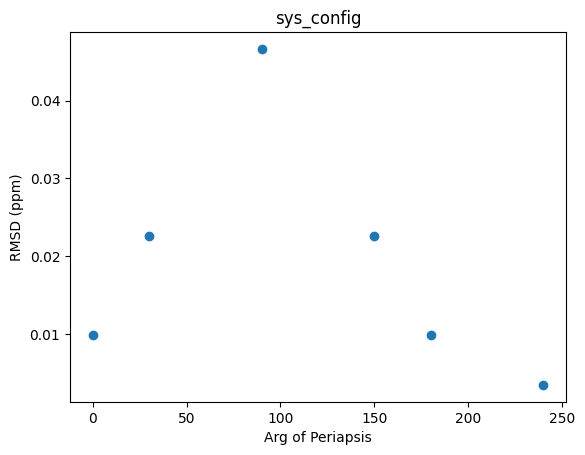

In [4]:
plt.scatter(per0s, RMSDs)
plt.xscale('linear')
plt.xlabel('Arg of Periapsis')
plt.ylabel('RMSD (ppm)')
plt.title('sys_config')
# plt.legend()

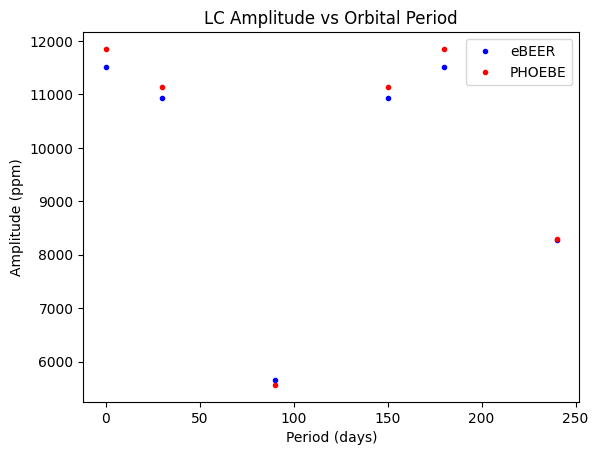

In [5]:
plt.plot(per0s, ebeer_ampl, 'b.', label= 'eBEER')
plt.plot(per0s, phoebe_ampl, 'r.', label= 'PHOEBE')
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Period (days)')
plt.ylabel('Amplitude (ppm)')
plt.title('LC Amplitude vs Orbital Period')
plt.legend()

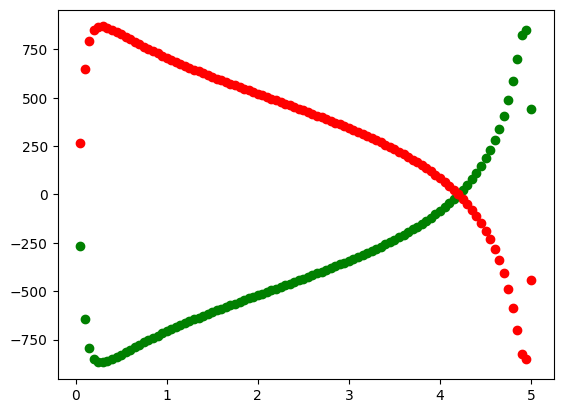

In [6]:
primary_beaming, secondary_beaming = get_ebeer_lc(b_, times, 1, 1, 0, 0, 'split', True)
plt.plot(phase, primary_beaming, 'og')
plt.plot(phase, secondary_beaming, 'or')